In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

# 👇 Change this path to where your dataset folder is inside Drive
dataset_path = "/content/drive/MyDrive/dataset"  # example path

# List folders (classes)
if os.path.exists(dataset_path):
    classes = os.listdir(dataset_path)
    print("✅ Dataset found!")
    print("Classes detected:", classes)
else:
    print("❌ Dataset path not found. Please check the folder name and update dataset_path.")


✅ Dataset found!
Classes detected: ['diseased', 'normal']


In [ ]:
import os

# Path to your dataset folder
dataset_path = "/content/drive/MyDrive/dataset"

# Initialize total counter
total_images = 0
class_counts = {}

# Loop through each class folder and count images
for class_name in os.listdir(dataset_path):
    class_dir = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_dir):
        count = len([f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        class_counts[class_name] = count
        total_images += count

print("📊 Total images in dataset:", total_images)
print("📂 Images per class:")
for class_name, count in class_counts.items():
    print(f"  {class_name}: {count}")


📊 Total images in dataset: 534
📂 Images per class:
  diseased: 285
  normal: 249


In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
import numpy as np

# Original dataset path
dataset_path = "/content/drive/MyDrive/dataset"

# Folder to save the augmented dataset
augmented_path = "/content/drive/MyDrive/arecanut_dataset_augmented"
os.makedirs(augmented_path, exist_ok=True)

# Create the same class subfolders
for cls in ['normal', 'diseased']:
    os.makedirs(os.path.join(augmented_path, cls), exist_ok=True)

# ImageDataGenerator for augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Number of augmented images per original image (approx. 3x)
augment_factor = 2  # 2 extra per original = 3× total

for class_name in ['normal', 'diseased']:
    class_dir = os.path.join(dataset_path, class_name)
    save_dir = os.path.join(augmented_path, class_name)
    images = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    print(f"Augmenting class '{class_name}' ({len(images)} original images)...")

    for img_name in images:
        img_path = os.path.join(class_dir, img_name)
        img = load_img(img_path, target_size=(224, 224))
        x = img_to_array(img)
        x = np.expand_dims(x, axis=0)

        i = 0
        for batch in datagen.flow(x, batch_size=1, save_to_dir=save_dir, save_prefix='aug', save_format='jpg'):
            i += 1
            if i >= augment_factor:
                break

print("✅ Augmentation complete! Augmented images saved to:", augmented_path)


Augmenting class 'normal' (249 original images)...
Augmenting class 'diseased' (285 original images)...
✅ Augmentation complete! Augmented images saved to: /content/drive/MyDrive/arecanut_dataset_augmented


In [ ]:
import os

augmented_path = "/content/drive/MyDrive/arecanut_dataset_augmented"

total_images_aug = 0
class_counts_aug = {}

for class_name in os.listdir(augmented_path):
    class_dir = os.path.join(augmented_path, class_name)
    if os.path.isdir(class_dir):
        count = len([f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        class_counts_aug[class_name] = count
        total_images_aug += count

print("📊 Total augmented images:", total_images_aug)
print("📂 Augmented images per class:")
for cls, cnt in class_counts_aug.items():
    print(f"  {cls}: {cnt}")


📊 Total augmented images: 1037
📂 Augmented images per class:
  normal: 487
  diseased: 550


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Path to augmented dataset
dataset_path = "/content/drive/MyDrive/arecanut_dataset_augmented"

# ImageDataGenerator with normalization and validation split
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2   # 80% training, 20% validation
)

# Training generator
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

# Validation generator
val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)


Found 830 images belonging to 2 classes.
Found 207 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

# Load EfficientNetB0 with pretrained ImageNet weights
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base model layers (so we train only the top layers first)
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)  # prevent overfitting
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)  # binary classification (normal vs diseased)

# Create final model
model = Model(inputs=base_model.input, outputs=output)

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Summary
model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import os

# 🔧 Editable training parameters
EPOCHS = 15                    # fixed to 15 (you can change if needed)
BATCH_SIZE = 32                # number of images per batch
STEPS_PER_EPOCH = 50           # 👈 directly editable number (example)
VALIDATION_STEPS = 10          # 👈 directly editable number (example)
TRAIN_DATA = train_generator
VAL_DATA = val_generator

# 📂 Folder to save model checkpoints
checkpoint_dir = "/content/drive/MyDrive/arecanut_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# ✅ Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint(
    filepath=os.path.join(checkpoint_dir, 'best_model_epoch{epoch:02d}_valacc{val_accuracy:.2f}.h5'),
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, verbose=1, min_lr=1e-6)

# 🚀 Train the model
history = model.fit(
    TRAIN_DATA,
    steps_per_epoch=STEPS_PER_EPOCH,     # you can directly type numbers like 20, 30, etc.
    epochs=EPOCHS,                       # fixed to 15 for now
    validation_data=VAL_DATA,
    validation_steps=VALIDATION_STEPS,   # directly editable
    callbacks=[early_stop, checkpoint, reduce_lr]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
26/50 ━━━━━━━━━━━━━━━━━━━━ 1:14 3s/step - accuracy: 0.4917 - loss: 0.7228

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_accuracy improved from -inf to 0.53140, saving model to /content/drive/MyDrive/arecanut_checkpoints/best_model_epoch01_valacc0.53.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.4968 - loss: 0.7195 - val_accuracy: 0.5314 - val_loss: 0.6973 - learning_rate: 0.0010
Epoch 2/15
26/50 ━━━━━━━━━━━━━━━━━━━━ 1:02 3s/step - accuracy: 0.5070 - loss: 0.7086
Epoch 2: val_accuracy did not improve from 0.53140
50/50 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.5019 - loss: 0.7106 - val_accuracy: 0.5314 - val_loss: 0.6909 - learning_rate: 0.0010
Epoch 3/15
26/50 ━━━━━━━━━━━━━━━━━━━━ 1:03 3s/step - accuracy: 0.5267 - loss: 0.6992
Epoch 3: val_accuracy did not improve from 0.53140
50/50 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.5087 - loss: 0.7008 - val_accuracy: 0.5314 - val_loss: 0.6920 - learning_rate: 0.0010
Epoch 4/15
26/50 ━━━━━━━━━━━━━━━━━━━━ 1:08 3s/step - accuracy: 0.5062 - loss: 0.6918
Epoch 4: val_accuracy did not improve from 0.53140
50/50 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.5148 - loss: 0.6913 - val_accuracy: 0.5314 - val_loss: 0.6921 - learning_rate: 0.0010
Epoch 5/15
26/50 ━━━━━━━━━━━━━━━━━━

✅ Fixed Steps:
Steps per epoch: 25
Validation steps: 6


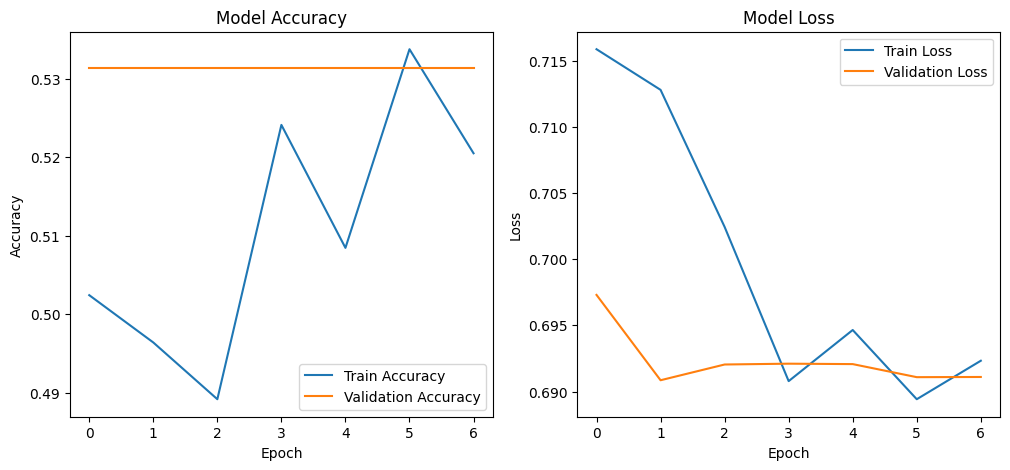

In [ ]:
import matplotlib.pyplot as plt

# ✅ Fix steps (use automatic calculation)
STEPS_PER_EPOCH = train_generator.samples // BATCH_SIZE
VALIDATION_STEPS = val_generator.samples // BATCH_SIZE

print("✅ Fixed Steps:")
print("Steps per epoch:", STEPS_PER_EPOCH)
print("Validation steps:", VALIDATION_STEPS)

# 📈 Plot accuracy and loss
plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [ ]:
from tensorflow.keras.optimizers import Adam

# 🔓 Unfreeze the last few layers of EfficientNet for fine-tuning
for layer in base_model.layers[-80:]:  # you can try -50, -100, etc. later
    layer.trainable = True

# Re-compile the model with a lower learning rate
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 🔧 Editable parameters
EPOCHS = 15
BATCH_SIZE = 32
STEPS_PER_EPOCH = 25
VALIDATION_STEPS = 6

# 🚀 Fine-tuning training (using same callbacks)
history_finetune = model.fit(
    train_generator,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=VALIDATION_STEPS,
    callbacks=[early_stop, checkpoint, reduce_lr]
)


Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5416 - loss: 0.7575
Epoch 1: val_accuracy improved from 0.53140 to 0.55729, saving model to /content/drive/MyDrive/arecanut_checkpoints/best_model_epoch01_valacc0.56.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 149s 5s/step - accuracy: 0.5407 - loss: 0.7571 - val_accuracy: 0.5573 - val_loss: 0.6870 - learning_rate: 1.0000e-05
Epoch 2/15
 1/25 ━━━━━━━━━━━━━━━━━━━━ 1:18 3s/step - accuracy: 0.5625 - loss: 0.6748
Epoch 2: val_accuracy did not improve from 0.55729
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 645ms/step - accuracy: 0.5625 - loss: 0.6748 - val_accuracy: 0.5312 - val_loss: 0.6909 - learning_rate: 1.0000e-05
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4993 - loss: 0.7343
Epoch 3: val_accuracy did not improve from 0.55729
25/25 ━━━━━━━━━━━━━━━━━━━━ 118s 5s/step - accuracy: 0.4996 - loss: 0.7338 - val_accuracy: 0.5104 - val_loss: 0.6941 - learning_rate: 1.0000e-05
Epoch 4/15
 1/25 ━━━━━━━━━━━━━━━━━━━━ 1:22 3s/step - accuracy: 0.5625 - loss: 0.7115
Epoch 4: val_accuracy did not improve from 0.55729

Epoch 4: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 622ms/step - accuracy: 0.5625 - loss: 0.7115 - val_

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
import os
from tensorflow.keras.optimizers import Adam

# 🔓 Unfreeze last 80 layers for fine-tuning
for layer in base_model.layers[-80:]:
    layer.trainable = True

# Recompile with a small learning rate
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 🔧 Editable parameters
EPOCHS = 20                # train full 20 epochs now
BATCH_SIZE = 32
STEPS_PER_EPOCH = 25       # you can change numbers anytime
VALIDATION_STEPS = 6

# 📂 Save best models automatically
checkpoint_dir = "/content/drive/MyDrive/arecanut_checkpoints_final"
os.makedirs(checkpoint_dir, exist_ok=True)

# ✅ Callbacks (without early stopping)
checkpoint = ModelCheckpoint(
    filepath=os.path.join(checkpoint_dir, 'best_model_epoch{epoch:02d}_valacc{val_accuracy:.2f}.h5'),
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

# 🚀 Train the model (no early stopping)
history_finetune = model.fit(
    train_generator,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=VALIDATION_STEPS,
    callbacks=[checkpoint, reduce_lr]
)


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5555 - loss: 0.7130
Epoch 1: val_accuracy improved from -inf to 0.54167, saving model to /content/drive/MyDrive/arecanut_checkpoints_final/best_model_epoch01_valacc0.54.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 145s 5s/step - accuracy: 0.5547 - loss: 0.7132 - val_accuracy: 0.5417 - val_loss: 0.6893 - learning_rate: 1.0000e-05
Epoch 2/20
 1/25 ━━━━━━━━━━━━━━━━━━━━ 1:26 4s/step - accuracy: 0.4375 - loss: 0.7495
Epoch 2: val_accuracy did not improve from 0.54167
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 663ms/step - accuracy: 0.4375 - loss: 0.7495 - val_accuracy: 0.5260 - val_loss: 0.6916 - learning_rate: 1.0000e-05
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5475 - loss: 0.7069
Epoch 3: val_accuracy improved from 0.54167 to 0.55208, saving model to /content/drive/MyDrive/arecanut_checkpoints_final/best_model_epoch03_valacc0.55.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 118s 5s/step - accuracy: 0.5469 - loss: 0.7069 - val_accuracy: 0.5521 - val_loss: 0.6876 - learning_rate: 1.0000e-05
Epoch 4/20
 1/25 ━━━━━━━━━━━━━━━━━━━━ 1:21 3s/step - accuracy: 0.5938 - loss: 0.7078
Epoch 4: val_accuracy did not improve from 0.55208
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 666ms/step - accuracy: 0.5938 - loss: 0.7078 - val_accuracy: 0.5417 - val_loss: 0.6891 - learning_rate: 1.0000e-05
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5469 - loss: 0.6902
Epoch 5: val_accuracy did not improve from 0.55208
25/25 ━━━━━━━━━━━━━━━━━━━━ 142s 6s/step - accuracy: 0.5464 - loss: 0.6902 - val_accuracy: 0.5104 - val_loss: 0.6932 - learning_rate: 1.0000e-05
Epoch 6/20
 1/25 ━━━━━━━━━━━━━━━━━━━━ 1:29 4s/step - accuracy: 0.5938 - loss: 0.6936
Epoch 6: val_accuracy did not improve from 0.55208

Epoch 6: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 705ms/step - accuracy: 0.5938 - loss: 0.6936 - val_

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 14: val_accuracy did not improve from 0.55208
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 646ms/step - accuracy: 0.5938 - loss: 0.6864 - val_accuracy: 0.5208 - val_loss: 0.6908 - learning_rate: 1.0000e-06
Epoch 15/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5925 - loss: 0.6774
Epoch 15: val_accuracy did not improve from 0.55208
25/25 ━━━━━━━━━━━━━━━━━━━━ 151s 4s/step - accuracy: 0.5920 - loss: 0.6775 - val_accuracy: 0.5208 - val_loss: 0.6907 - learning_rate: 1.0000e-06
Epoch 16/20
 1/25 ━━━━━━━━━━━━━━━━━━━━ 1:55 5s/step - accuracy: 0.5312 - loss: 0.6736
Epoch 16: val_accuracy did not improve from 0.55208
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 636ms/step - accuracy: 0.5312 - loss: 0.6736 - val_accuracy: 0.5260 - val_loss: 0.6902 - learning_rate: 1.0000e-06
Epoch 17/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5628 - loss: 0.6915
Epoch 17: val_accuracy did not improve from 0.55208
25/25 ━━━━━━━━━━━━━━━━━━━━ 121s 4s/step - accuracy: 0.5633 - loss: 0.6912 - val_accuracy: 0.5208 - va

7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step


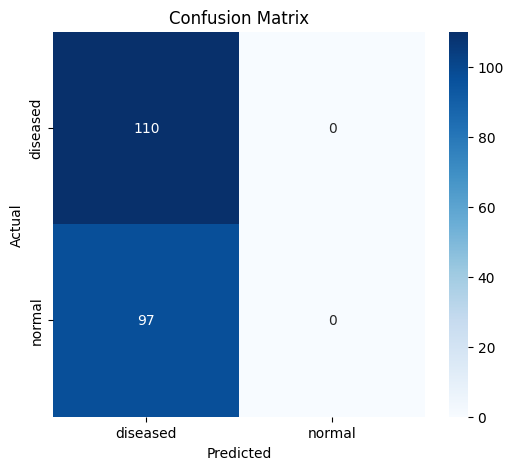

📊 Classification Report:
              precision    recall  f1-score   support

    diseased       0.53      1.00      0.69       110
      normal       0.00      0.00      0.00        97

    accuracy                           0.53       207
   macro avg       0.27      0.50      0.35       207
weighted avg       0.28      0.53      0.37       207

✅ Validation Accuracy: 0.5314009661835749


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ Load best model
from tensorflow.keras.models import load_model

best_model_path = '/content/drive/MyDrive/arecanut_checkpoints_final/best_model_epoch03_valacc0.55.h5'  # 👈 change if another epoch was best
model = load_model(best_model_path)

# Generate predictions on validation data
val_generator.reset()
preds = model.predict(val_generator)
pred_classes = (preds > 0.5).astype("int32").flatten()
true_classes = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification report
print("📊 Classification Report:")
print(classification_report(true_classes, pred_classes, target_names=class_labels))

# Overall accuracy
print("✅ Validation Accuracy:", accuracy_score(true_classes, pred_classes))


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
import os
from sklearn.utils import class_weight
import numpy as np

# --- 1️⃣ Enhanced Data Augmentation ---
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_path = "/content/drive/MyDrive/arecanut_dataset_augmented"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

# --- 2️⃣ Rebuild model and unfreeze more layers ---
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
for layer in base_model.layers[-150:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# --- 3️⃣ Class weights to fix imbalance ---
class_labels = list(train_generator.class_indices.keys())
y_train = train_generator.classes
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i : weights[i] for i in range(len(weights))}
print("⚖️ Class Weights:", class_weights)

# --- 4️⃣ Checkpoint setup ---
checkpoint_dir = "/content/drive/MyDrive/arecanut_checkpoints_v2"
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint = ModelCheckpoint(
    filepath=os.path.join(checkpoint_dir, 'best_model_epoch{epoch:02d}_valacc{val_accuracy:.2f}.keras'),
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1, min_lr=1e-6)

# --- 5️⃣ Training ---
EPOCHS = 25
STEPS_PER_EPOCH = 25
VALIDATION_STEPS = 6

history_v2 = model.fit(
    train_generator,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=VALIDATION_STEPS,


    class_weight=class_weights,
    callbacks=[checkpoint, reduce_lr]
)


Found 830 images belonging to 2 classes.
Found 207 images belonging to 2 classes.
⚖️ Class Weights: {0: np.float64(0.9431818181818182), 1: np.float64(1.064102564102564)}


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.5997 - loss: 0.6536 
Epoch 1: val_accuracy improved from -inf to 0.45833, saving model to /content/drive/MyDrive/arecanut_checkpoints_v2/best_model_epoch01_valacc0.46.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 392s 13s/step - accuracy: 0.6043 - loss: 0.6491 - val_accuracy: 0.4583 - val_loss: 0.7019 - learning_rate: 1.0000e-04
Epoch 2/25
 1/25 ━━━━━━━━━━━━━━━━━━━━ 4:28 11s/step - accuracy: 0.7500 - loss: 0.4503

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.45833 to 0.47917, saving model to /content/drive/MyDrive/arecanut_checkpoints_v2/best_model_epoch02_valacc0.48.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 813ms/step - accuracy: 0.7500 - loss: 0.4503 - val_accuracy: 0.4792 - val_loss: 0.6993 - learning_rate: 1.0000e-04
Epoch 3/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.8924 - loss: 0.2901 
Epoch 3: val_accuracy did not improve from 0.47917
25/25 ━━━━━━━━━━━━━━━━━━━━ 381s 15s/step - accuracy: 0.8923 - loss: 0.2894 - val_accuracy: 0.4583 - val_loss: 0.7153 - learning_rate: 1.0000e-04
Epoch 4/25
 1/25 ━━━━━━━━━━━━━━━━━━━━ 4:39 12s/step - accuracy: 0.9375 - loss: 0.1580
Epoch 4: val_accuracy did not improve from 0.47917
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9375 - loss: 0.1580 - val_accuracy: 0.4635 - val_loss: 0.7140 - learning_rate: 1.0000e-04
Epoch 5/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.8962 - loss: 0.2454 
Epoch 5: val_accuracy did not improve from 0.47917



7/7 ━━━━━━━━━━━━━━━━━━━━ 33s 5s/step
✅ Validation Accuracy: 51.69%

📊 Classification Report:
              precision    recall  f1-score   support

    diseased       0.65      0.20      0.31       110
      normal       0.49      0.88      0.63        97

    accuracy                           0.52       207
   macro avg       0.57      0.54      0.47       207
weighted avg       0.57      0.52      0.46       207



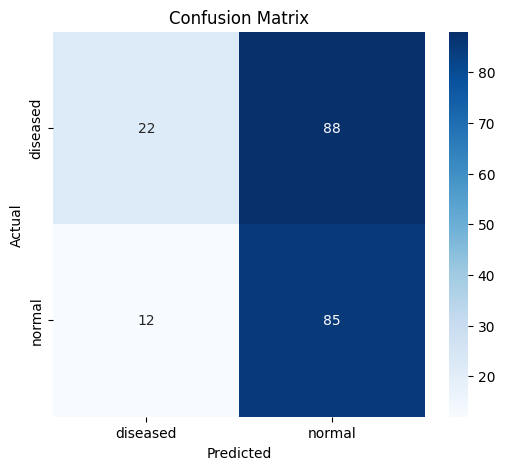

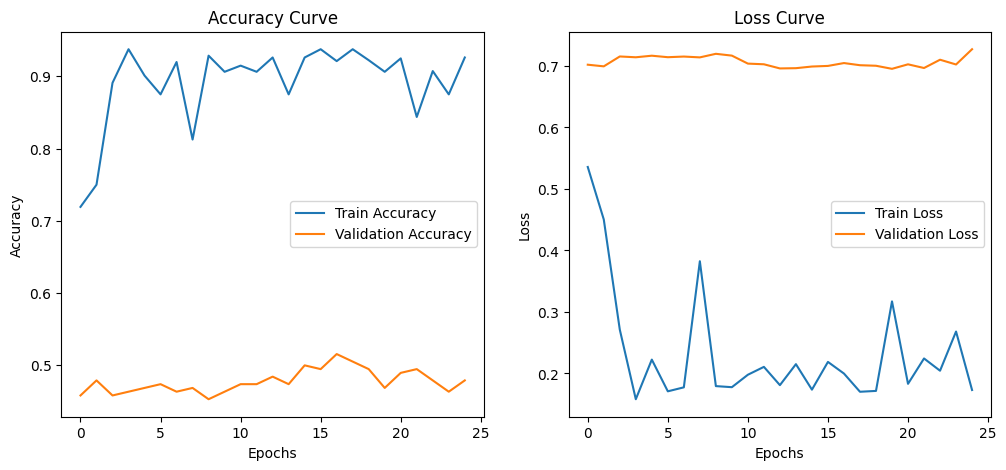

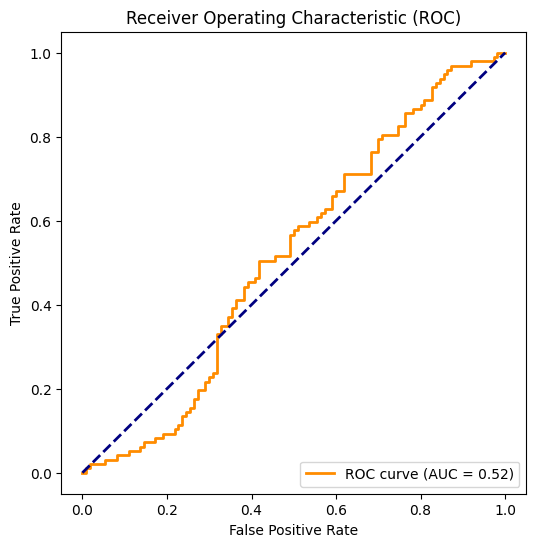

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score
import seaborn as sns
from tensorflow.keras.models import load_model

# --- Load the best saved model ---
best_model_path = "/content/drive/MyDrive/arecanut_checkpoints_v2/best_model_epoch17_valacc0.52.keras"  # 👈 update if different
model = load_model(best_model_path)

# --- Generate predictions on validation set ---
val_generator.reset()
pred_probs = model.predict(val_generator)
pred_classes = (pred_probs > 0.5).astype("int32").flatten()
true_classes = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# --- 1️⃣ Overall Accuracy ---
accuracy = accuracy_score(true_classes, pred_classes)
print(f"✅ Validation Accuracy: {accuracy*100:.2f}%")

# --- 2️⃣ Classification Report ---
print("\n📊 Classification Report:")
print(classification_report(true_classes, pred_classes, target_names=class_labels))

# --- 3️⃣ Confusion Matrix ---
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# --- 4️⃣ Accuracy & Loss Curves ---
try:
    hist = history_v2  # if your training history variable name is different, replace it here

    plt.figure(figsize=(12,5))

    # Accuracy curve
    plt.subplot(1,2,1)
    plt.plot(hist.history['accuracy'], label='Train Accuracy')
    plt.plot(hist.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss curve
    plt.subplot(1,2,2)
    plt.plot(hist.history['loss'], label='Train Loss')
    plt.plot(hist.history['val_loss'], label='Validation Loss')
    plt.title('Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()
except Exception as e:
    print("⚠️ History not found in this session. Please re-run training if needed.")

# --- 5️⃣ ROC & AUC Curve ---
fpr, tpr, _ = roc_curve(true_classes, pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()


In [ ]:
from tensorflow.keras.models import load_model

# 👇 Path to your best model file
best_model_path = "/content/drive/MyDrive/arecanut_checkpoints_EfficientNetB3/best_model_epoch17_valacc0.52.keras"

# Load the best model
model = load_model(best_model_path)

# Save it permanently
model.save("/content/drive/MyDrive/arecanut_final_model.keras")

print("✅ Model saved successfully at /content/drive/MyDrive/arecanut_final_model.keras")


ValueError: File not found: filepath=/content/drive/MyDrive/arecanut_checkpoints_EfficientNetB3/best_model_epoch17_valacc0.52.keras. Please ensure the file is an accessible `.keras` zip file.

In [ ]:
import os
folder = "/content/drive/MyDrive/arecanut_checkpoints_EfficientNetB3"
print("Files in:", folder)
for f in os.listdir(folder):
    print(f)


Files in: /content/drive/MyDrive/arecanut_checkpoints_EfficientNetB3


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)


Mounted at /content/drive


In [ ]:
import os
folder = "/content/drive/MyDrive/arecanut_checkpoints_EfficientNetB3"
print("📁 Files inside:", folder)
for f in os.listdir(folder):
    print(" -", f)


📁 Files inside: /content/drive/MyDrive/arecanut_checkpoints_EfficientNetB3


In [ ]:
import os

folders = [
    "/content/drive/MyDrive/arecanut_checkpoints",
    "/content/drive/MyDrive/arecanut_checkpoints_final",
    "/content/drive/MyDrive/arecanut_checkpoints_v2",
    "/content/drive/MyDrive/arecanut_checkpoints_EfficientNetB3"
]

for folder in folders:
    print(f"\n📂 Checking: {folder}")
    if os.path.exists(folder):
        files = os.listdir(folder)
        if files:
            for f in files:
                print(" -", f)
        else:
            print("   (empty)")
    else:
        print("   ❌ Folder not found")



📂 Checking: /content/drive/MyDrive/arecanut_checkpoints
 - best_model_epoch01_valacc0.53.h5
 - best_model_epoch01_valacc0.56.h5

📂 Checking: /content/drive/MyDrive/arecanut_checkpoints_final
 - best_model_epoch01_valacc0.54.h5
 - best_model_epoch03_valacc0.55.h5

📂 Checking: /content/drive/MyDrive/arecanut_checkpoints_v2
 - best_model_epoch01_valacc0.46.keras
 - best_model_epoch02_valacc0.48.keras
 - best_model_epoch13_valacc0.48.keras
 - best_model_epoch15_valacc0.50.keras
 - best_model_epoch17_valacc0.52.keras

📂 Checking: /content/drive/MyDrive/arecanut_checkpoints_EfficientNetB3
   (empty)


In [ ]:
from tensorflow.keras.models import load_model

# ✅ Correct path to your best model
best_model_path = "/content/drive/MyDrive/arecanut_checkpoints_v2/best_model_epoch17_valacc0.52.keras"

# Load the model
model = load_model(best_model_path)

# Save it permanently as your final model
model.save("/content/drive/MyDrive/arecanut_final_model.keras")

print("✅ Model saved successfully at /content/drive/MyDrive/arecanut_final_model.keras")


✅ Model saved successfully at /content/drive/MyDrive/arecanut_final_model.keras


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving 20230227_145238.jpg to 20230227_145238.jpg


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# 🔹 Load your final saved model
model_path = "/content/drive/MyDrive/arecanut_final_model.keras"
model = load_model(model_path)

# 🔹 Load and preprocess your uploaded image
img_path = "20230227_145238.jpg"  # uploaded file name
img = image.load_img(img_path, target_size=(300, 300))  # resize same as training
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# 🔹 Predict
prediction = model.predict(img_array)[0][0]

# 🔹 Display image and result
plt.imshow(image.load_img(img_path))
plt.axis("off")

if prediction > 0.5:
    label = "🌿 Normal Arecanut"
else:
    label = "⚠️ Diseased Arecanut"

plt.title(f"Prediction: {label}\n(Confidence: {prediction:.2f})", fontsize=14)
plt.show()


ValueError: Input 0 of layer "functional_1" is incompatible with the layer: expected shape=(None, 224, 224, 3), found shape=(1, 300, 300, 3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


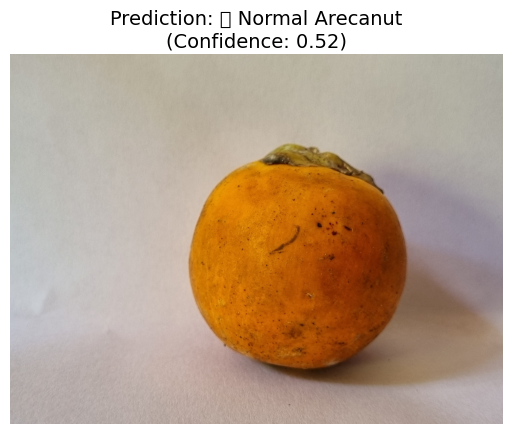

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# ✅ Load your final saved model
model_path = "/content/drive/MyDrive/arecanut_final_model.keras"
model = load_model(model_path)

# ✅ Load and preprocess your uploaded image
img_path = "20230227_145238.jpg"  # uploaded file name
img = image.load_img(img_path, target_size=(224, 224))  # changed to 224x224
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# ✅ Predict
prediction = model.predict(img_array)[0][0]

# ✅ Display image and result
plt.imshow(image.load_img(img_path))
plt.axis("off")

if prediction > 0.5:
    label = "🌿 Normal Arecanut"
else:
    label = "⚠️ Diseased Arecanut"

plt.title(f"Prediction: {label}\n(Confidence: {prediction:.2f})", fontsize=14)
plt.show()


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam

# 1) Load your previously saved model
model_path = "/content/drive/MyDrive/arecanut_final_model.keras"
model = load_model(model_path)
print("✅ Loaded model from:", model_path)

# 2) Unfreeze the TOP 50 layers for gentle fine-tuning
#    (keeps most layers frozen so we don't overfit)
total_layers = len(model.layers)
unfreeze_count = 50
for layer in model.layers[-unfreeze_count:]:
    layer.trainable = True

# Keep the rest frozen
for layer in model.layers[:-unfreeze_count]:
    layer.trainable = False

# 3) Re-compile with a very small learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# 4) Quick summary
trainable = sum([int(l.trainable) for l in model.layers])
print(f"🧠 Total layers: {total_layers} | 🔓 Trainable now: {trainable} (last {unfreeze_count})")


✅ Loaded model from: /content/drive/MyDrive/arecanut_final_model.keras
🧠 Total layers: 243 | 🔓 Trainable now: 50 (last 50)


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
import os

# Folder to save fine-tuned checkpoints
fine_tune_dir = "/content/drive/MyDrive/arecanut_finetuned"
os.makedirs(fine_tune_dir, exist_ok=True)

# Callbacks
checkpoint = ModelCheckpoint(
    filepath=os.path.join(fine_tune_dir, "finetuned_epoch{epoch:02d}_valacc{val_accuracy:.2f}.keras"),
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    verbose=1,
    min_lr=1e-6
)

# Fine-tune training settings
EPOCHS = 5
STEPS_PER_EPOCH = 20
VALIDATION_STEPS = 6

history_finetune2 = model.fit(
    train_generator,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=VALIDATION_STEPS,
    callbacks=[checkpoint, reduce_lr]
)


NameError: name 'train_generator' is not defined

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Path to your dataset
dataset_path = "/content/drive/MyDrive/arecanut_dataset_augmented"

# Recreate ImageDataGenerator with same parameters
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.2,
    zoom_range=0.3,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    validation_split=0.2
)

# Recreate generators
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)


Found 830 images belonging to 2 classes.
Found 207 images belonging to 2 classes.


In [ ]:
# ✅ Evaluate fine-tuned model directly
val_loss, val_acc = model.evaluate(val_generator)
print(f"\n🌱 Fine-tuned Model Validation Accuracy: {val_acc*100:.2f}%")
print(f"📉 Validation Loss: {val_loss:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


7/7 ━━━━━━━━━━━━━━━━━━━━ 85s 3s/step - accuracy: 0.4559 - loss: 0.6916

🌱 Fine-tuned Model Validation Accuracy: 47.83%
📉 Validation Loss: 0.6952


In [ ]:
model.save("/content/drive/MyDrive/arecanut_final_model_v2.keras")
print("✅ Fine-tuned model saved at /content/drive/MyDrive/arecanut_final_model_v2.keras")


✅ Fine-tuned model saved at /content/drive/MyDrive/arecanut_final_model_v2.keras


In [ ]:
import os

project_dir = "/content/arecanut_website"
os.makedirs(project_dir, exist_ok=True)
os.chdir(project_dir)

print("✅ Project folder created at:", project_dir)


✅ Project folder created at: /content/arecanut_website


In [ ]:
from pyngrok import ngrok
ngrok.set_auth_token("350yxxff9eizlIN4MscSoHsDEVO_6dhjFZrKQnjxCSQB5gpDG")



In [ ]:
from pyngrok import ngrok
import os

# Kill any previous tunnels
ngrok.kill()
os.system("pkill gunicorn")

# Start your Flask app in the background
get_ipython().system_raw('python3 app.py &')

# Create a new public tunnel
public_url = ngrok.connect(5000)
print("🌐 Your Arecanut Detection Website is live at:", public_url)


🌐 Your Arecanut Detection Website is live at: NgrokTunnel: "https://unvitalized-dwain-juvenilely.ngrok-free.dev" -> "http://localhost:5000"


In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!fuser -k 5000/tcp
!python arecanut_website/app.py --port=5001



python3: can't open file '/content/arecanut_website/app.py': [Errno 2] No such file or directory


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)



Mounted at /content/drive


In [ ]:
!fusermount -u /content/drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive | grep arecanut_final_model_v2.keras


arecanut_final_model_v2.keras


In [ ]:
!ls /content/drive/MyDrive | grep arecanut_final_model_v2.keras


arecanut_final_model_v2.keras


In [ ]:
import os
from glob import glob

# Common possible dataset locations
candidates = [
    "/content/drive/MyDrive/arecanut_dataset_augmented",
    "/content/drive/MyDrive/arecanut_dataset",
    "/content/drive/MyDrive/dataset",
    "/content/drive/MyDrive/arecanut",
    "/content/drive/MyDrive",
]

def summarize(path):
    if not os.path.isdir(path):
        return
    print(f"\n✅ Found folder: {path}")
    subfolders = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]
    print("📁 Subfolders:", subfolders[:10])  # show first 10 subfolders
    for f in subfolders:
        if f.lower() in ["train", "training", "val", "validation", "test"]:
            print(f"🔍 -> Possible dataset folder: {os.path.join(path, f)}")

for path in candidates:
    summarize(path)




✅ Found folder: /content/drive/MyDrive/arecanut_dataset_augmented
📁 Subfolders: ['normal', 'diseased']

✅ Found folder: /content/drive/MyDrive/dataset
📁 Subfolders: ['diseased', 'normal']

✅ Found folder: /content/drive/MyDrive
📁 Subfolders: ['Classroom', 'Colab Notebooks', 'dataset', 'arecanut_dataset_augmented', 'arecanut_checkpoints', 'arecanut_checkpoints_final', 'arecanut_checkpoints_v2', 'arecanut_checkpoints_EfficientNetB3', 'arecanut_finetuned']


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

# ✅ Load your previous model
model_path = "/content/drive/MyDrive/arecanut_final_model_v2.keras"
model = load_model(model_path)
print("✅ Model loaded successfully!")

# ✅ Allow all layers to be trainable
for layer in model.layers:
    layer.trainable = True

# ✅ Compile with a lower learning rate for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ✅ Use ImageDataGenerator to split dataset automatically
dataset_path = "/content/drive/MyDrive/arecanut_dataset_augmented"

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # 80% training, 20% validation
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

# ✅ Train model again (fine-tuning)
history_finetune = model.fit(
    train_generator,



    validation_data=val_generator,
    epochs=5
)

# ✅ Save improved model
model.save("/content/drive/MyDrive/arecanut_final_model_v3.keras")
print("🎯 Fine-tuned model saved as arecanut_final_model_v3.keras")


✅ Model loaded successfully!
Found 830 images belonging to 2 classes.
Found 207 images belonging to 2 classes.
Epoch 1/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 333s 11s/step - accuracy: 0.9135 - loss: 0.2044 - val_accuracy: 0.4831 - val_loss: 0.6979
Epoch 2/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 319s 10s/step - accuracy: 0.9233 - loss: 0.1590 - val_accuracy: 0.5024 - val_loss: 0.7009
Epoch 3/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 273s 11s/step - accuracy: 0.9367 - loss: 0.1818 - val_accuracy: 0.5507 - val_loss: 0.6991
Epoch 4/5
 8/26 ━━━━━━━━━━━━━━━━━━━━ 2:55 10s/step - accuracy: 0.8831 - loss: 0.1947

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

# ✅ Load your previous model
model_path = "/content/drive/MyDrive/arecanut_final_model_v2.keras"
model = load_model(model_path)
print("✅ Model loaded successfully!")

# ✅ Allow all layers to be trainable
for layer in model.layers:
    layer.trainable = True

# ✅ Compile with a lower learning rate for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ✅ Use ImageDataGenerator to split dataset automatically
dataset_path = "/content/drive/MyDrive/arecanut_dataset_augmented"

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # 80% training, 20% validation
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

# ✅ Train model again (fine-tuning)
history_finetune = model.fit(
    train_generator,



    validation_data=val_generator,
    epochs=3
)

# ✅ Save improved model
model.save("/content/drive/MyDrive/arecanut_final_model_v3.keras")
print("🎯 Fine-tuned model saved as arecanut_final_model_v3.keras")


✅ Model loaded successfully!
Found 830 images belonging to 2 classes.
Found 207 images belonging to 2 classes.
Epoch 1/3
26/26 ━━━━━━━━━━━━━━━━━━━━ 325s 11s/step - accuracy: 0.9164 - loss: 0.1860 - val_accuracy: 0.5024 - val_loss: 0.6965
Epoch 2/3
26/26 ━━━━━━━━━━━━━━━━━━━━ 270s 10s/step - accuracy: 0.9397 - loss: 0.1587 - val_accuracy: 0.5024 - val_loss: 0.6973
Epoch 3/3
26/26 ━━━━━━━━━━━━━━━━━━━━ 271s 10s/step - accuracy: 0.9438 - loss: 0.1413 - val_accuracy: 0.5314 - val_loss: 0.7032
🎯 Fine-tuned model saved as arecanut_final_model_v3.keras


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Add callbacks to avoid overfitting and dynamically reduce learning rate
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7)

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,  # increase to 20
    callbacks=[early_stop, reduce_lr]
)

# Save best fine-tuned version
model.save("/content/drive/MyDrive/arecanut_final_model_v4.keras")
print("✅ Model fine-tuned further and saved as arecanut_final_model_v4.keras")


Epoch 1/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 281s 11s/step - accuracy: 0.9229 - loss: 0.1667 - val_accuracy: 0.5024 - val_loss: 0.7252 - learning_rate: 1.0000e-05
Epoch 2/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 318s 11s/step - accuracy: 0.9399 - loss: 0.1392 - val_accuracy: 0.4783 - val_loss: 0.8296 - learning_rate: 1.0000e-05
Epoch 3/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 271s 10s/step - accuracy: 0.9448 - loss: 0.1442 - val_accuracy: 0.4879 - val_loss: 0.9586 - learning_rate: 1.0000e-05
Epoch 4/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 271s 10s/step - accuracy: 0.9371 - loss: 0.1407 - val_accuracy: 0.4831 - val_loss: 1.0529 - learning_rate: 2.0000e-06
Epoch 5/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 332s 11s/step - accuracy: 0.9205 - loss: 0.1645 - val_accuracy: 0.4976 - val_loss: 0.9803 - learning_rate: 2.0000e-06
✅ Model fine-tuned further and saved as arecanut_final_model_v4.keras


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# ✅ Load the trained model
model = load_model("/content/drive/MyDrive/arecanut_final_model_v3.keras")
print("✅ Model loaded successfully for prediction!")


✅ Model loaded successfully for prediction!


In [ ]:
import cv2

def predict_arecanut(image_path):
    # Load image
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0

    # Predict
    prediction = model.predict(img_array)[0][0]

    # Show image
    plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
    plt.axis('off')

    # Class labels
    if prediction > 0.5:
        plt.title("🌿 Diseased Arecanut")
        print("Prediction: Diseased Arecanut 🌿")
    else:
        plt.title("🍃 Healthy Arecanut")
        print("Prediction: Healthy Arecanut 🍃")

    plt.show()


In [ ]:
import os

folder_path = "/content/drive/MyDrive/arecanut_dataset_augmented/normal"

# list first few image names
print("📸 Images inside folder:")
print(os.listdir(folder_path)[:10])


📸 Images inside folder:
['aug_0_1850.jpg', 'aug_0_9785.jpg', 'aug_0_1711.jpg', 'aug_0_9091.jpg', 'aug_0_7203.jpg', 'aug_0_4552.jpg', 'aug_0_42.jpg', 'aug_0_9763.jpg', 'aug_0_7051.jpg', 'aug_0_7275.jpg']


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Prediction: Diseased Arecanut 🌿


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


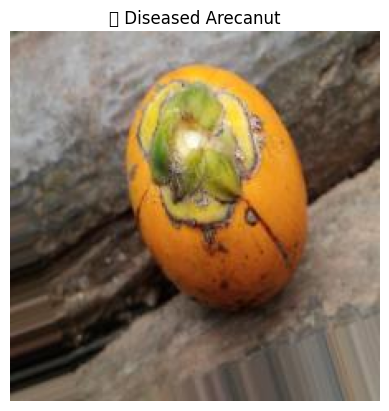

In [ ]:
test_image = "/content/drive/MyDrive/arecanut_dataset_augmented/normal/aug_0_1850.jpg" # Using a filename from the previous cell's output
predict_arecanut(test_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
Prediction: Diseased Arecanut 🌿


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


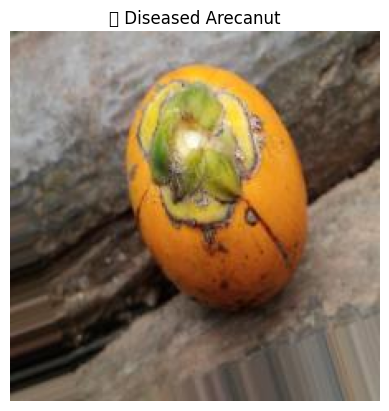

In [ ]:
test_image = "/content/drive/MyDrive/arecanut_dataset_augmented/normal/aug_0_1850.jpg"
predict_arecanut(test_image)


In [ ]:

!pip install gradio


In [ ]:
import gradio as gr
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import cv2

# ✅ Load your trained model
model_path = "/content/drive/MyDrive/arecanut_final_model_v3.keras"
model = load_model(model_path)
print("✅ Model loaded successfully!")

# ✅ Define prediction function
def predict_arecanut(img):
    # Resize and preprocess
    img = cv2.resize(img, (224, 224))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    # Predict
    prediction = model.predict(img)[0][0]

    # Output text and label
    if prediction > 0.5:
        result = "🌿 Diseased Arecanut"
    else:
        result = "🍃 Healthy Arecanut"

    return result

# ✅ Create Gradio interface
interface = gr.Interface(
    fn=predict_arecanut,
    inputs=gr.Image(type="numpy", label="Upload Arecanut Image"),
    outputs=gr.Textbox(label="Prediction Result"),
    title="🌿 Arecanut Disease Detection System",
    description="Upload an image of Arecanut leaf, nut, or trunk to detect if it's diseased or healthy.",
    theme="default"
)

# ✅ Launch the app
interface.launch(share=True)


✅ Model loaded successfully!
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2161ff985964e07a88.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import os

train_dir = "/content/drive/MyDrive/arecanut_dataset_augmented"
val_dir = "/content/drive/MyDrive/dataset"

print("✅ Train Folder:", train_dir, "— Subfolders:", os.listdir(train_dir))
print("✅ Validation Folder:", val_dir, "— Subfolders:", os.listdir(val_dir))


✅ Train Folder: /content/drive/MyDrive/arecanut_dataset_augmented — Subfolders: ['normal', 'diseased']
✅ Validation Folder: /content/drive/MyDrive/dataset — Subfolders: ['diseased', 'normal']


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras import layers, models, optimizers, callbacks

# Step 1: Image preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary'
)

# Step 2: Load pretrained model
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Step 3: Build new top layers
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=optimizers.Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Step 4: Train model
early_stop = callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop]
)

# Step 5: Save improved model
model.save('/content/drive/MyDrive/arecanut_final_model_v5.keras')
print("✅ Model trained and saved as arecanut_final_model_v5.keras")


Found 1037 images belonging to 2 classes.
Found 534 images belonging to 2 classes.
Epoch 1/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 266s 4s/step - accuracy: 0.4979 - loss: 0.7053 - val_accuracy: 0.5562 - val_loss: 0.6815
Epoch 2/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 239s 4s/step - accuracy: 0.5275 - loss: 0.6927 - val_accuracy: 0.5337 - val_loss: 0.7061
Epoch 3/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 241s 4s/step - accuracy: 0.5392 - loss: 0.6939 - val_accuracy: 0.6199 - val_loss: 0.6784
Epoch 4/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 286s 4s/step - accuracy: 0.5866 - loss: 0.6764 - val_accuracy: 0.4944 - val_loss: 0.6805
Epoch 5/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 238s 4s/step - accuracy: 0.5540 - loss: 0.6882 - val_accuracy: 0.5449 - val_loss: 0.6766
Epoch 6/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 236s 4s/step - accuracy: 0.5620 - loss: 0.6782 - val_accuracy: 0.6273 - val_loss: 0.6751
Epoch 7/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 262s 4s/step - accuracy: 0.5834 - loss: 0.6813 - val_accuracy: 0.7097 - val_loss: 0.6761
Epoch 8/15
65/65 ━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


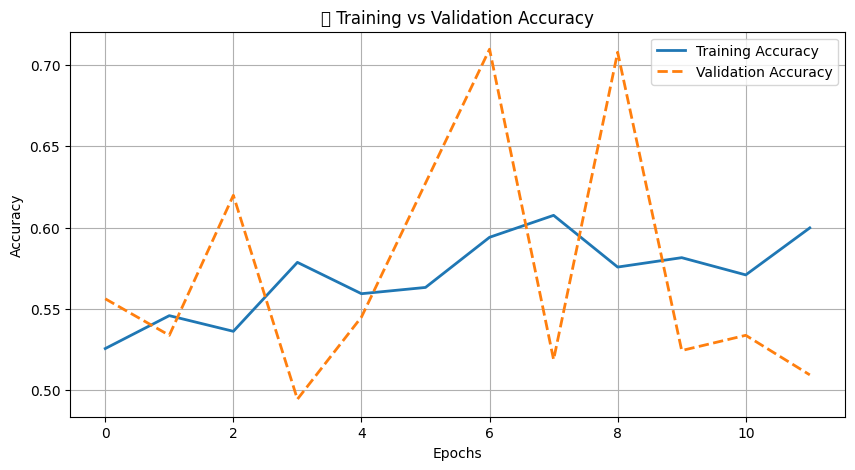

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


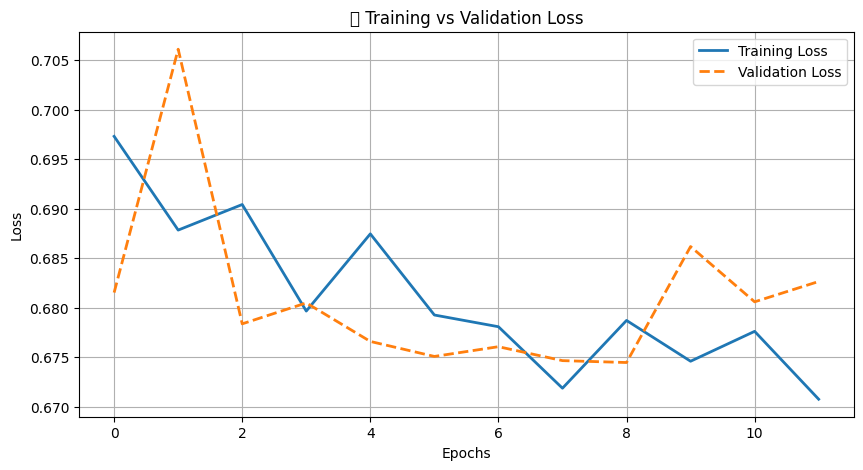

✅ Final Training Accuracy: 59.98%
✅ Final Validation Accuracy: 50.94%


In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, linestyle='--')
plt.title('📈 Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot training and validation loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--')
plt.title('📉 Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Print final metrics
final_train_acc = history.history['accuracy'][-1] * 100
final_val_acc = history.history['val_accuracy'][-1] * 100
print(f"✅ Final Training Accuracy: {final_train_acc:.2f}%")
print(f"✅ Final Validation Accuracy: {final_val_acc:.2f}%")


In [ ]:
import gradio as gr
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import cv2

# ✅ Load your trained model
model_path = "/content/drive/MyDrive/arecanut_final_model_v5.keras"
model = load_model(model_path)
print("✅ Model loaded successfully!")

# ✅ Define prediction function
def predict_arecanut(img):
    # Resize and preprocess
    img = cv2.resize(img, (224, 224))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    # Predict
    prediction = model.predict(img)[0][0]

    # Output text and label
    if prediction > 0.5:
        result = "🌿 Diseased Arecanut"
    else:
        result = "🍃 Healthy Arecanut"

    return result

# ✅ Create Gradio interface
interface = gr.Interface(
    fn=predict_arecanut,
    inputs=gr.Image(type="numpy", label="Upload Arecanut Image"),
    outputs=gr.Textbox(label="Prediction Result"),
    title="🌿 Arecanut Disease Detection System",
    description="Upload an image of Arecanut leaf, nut, or trunk to detect if it's diseased or healthy.",
    theme="default"
)

# ✅ Launch the app
interface.launch(share=True)


✅ Model loaded successfully!
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b83df49f9383857263.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import os

train_dir = "/content/drive/MyDrive/arecanut_dataset_augmented"
val_dir = "/content/drive/MyDrive/dataset"

print("🔍 Checking Dataset Folder Structure...\n")

# Check training folder
if os.path.exists(train_dir):
    print(f"✅ Training folder found at: {train_dir}")
    print("   Subfolders:", os.listdir(train_dir))
else:
    print(f"❌ Training folder NOT found at: {train_dir}")

# Check validation folder
if os.path.exists(val_dir):
    print(f"\n✅ Validation folder found at: {val_dir}")
    print("   Subfolders:", os.listdir(val_dir))
else:
    print(f"\n❌ Validation folder NOT found at: {val_dir}")

# Count image files in each subfolder
def count_images(folder):
    total = 0
    for sub in os.listdir(folder):
        path = os.path.join(folder, sub)
        if os.path.isdir(path):
            total += len([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    return total

print(f"\n📸 Total training images: {count_images(train_dir)}")
print(f"📸 Total validation images: {count_images(val_dir)}")


🔍 Checking Dataset Folder Structure...

✅ Training folder found at: /content/drive/MyDrive/arecanut_dataset_augmented
   Subfolders: ['normal', 'diseased']

✅ Validation folder found at: /content/drive/MyDrive/dataset
   Subfolders: ['diseased', 'normal']

📸 Total training images: 1037
📸 Total validation images: 534


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras import layers, Model

# ✅ Load existing model
model_path = "/content/drive/MyDrive/arecanut_final_model_v5.keras"
model = load_model(model_path)
print("✅ Model loaded successfully from:", model_path)

# ✅ Check model summary
model.summary()


✅ Model loaded successfully from: /content/drive/MyDrive/arecanut_final_model_v5.keras


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,964,724 (45.64 MB)

 Trainable params: 393,729 (1.50 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

 Optimizer params: 787,460 (3.00 MB)

In [ ]:
# ✅ Unfreeze the last few EfficientNet layers for deeper fine-tuning
fine_tune_from = 200  # you can change to 150 if overfitting occurs
for layer in model.layers[:fine_tune_from]:
    layer.trainable = False
for layer in model.layers[fine_tune_from:]:
    layer.trainable = True

# ✅ Recompile model with a very small learning rate
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("✅ Model ready for fine-tuning — layers unfrozen from:", fine_tune_from)


✅ Model ready for fine-tuning — layers unfrozen from: 200


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "/content/drive/MyDrive/arecanut_dataset_augmented"
val_dir = "/content/drive/MyDrive/dataset"

# ✅ Improved augmentation setup
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

# ✅ Load images
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary'
)

print("✅ Data generators ready.")


Found 1037 images belonging to 2 classes.
Found 534 images belonging to 2 classes.
✅ Data generators ready.


In [ ]:
import os
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

# ✅ Create checkpoint folder
fine_tune_checkpoint_dir = "/content/drive/MyDrive/arecanut_finetuned_v5"
os.makedirs(fine_tune_checkpoint_dir, exist_ok=True)

# ✅ Callbacks
checkpoint = ModelCheckpoint(
    filepath=os.path.join(fine_tune_checkpoint_dir, "best_model_epoch{epoch:02d}_valacc{val_accuracy:.2f}.keras"),
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# ✅ Fine-tune training
EPOCHS = 20

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[checkpoint, reduce_lr, early_stop],
    verbose=1
)

# ✅ Save final fine-tuned model
model.save("/content/drive/MyDrive/arecanut_final_model_v7.keras")
print("✅ Fine-tuning complete. Model saved as arecanut_final_model_v7.keras")


NameError: name 'model' is not defined

In [ ]:
from tensorflow.keras.models import load_model

# ✅ Load your last trained model (v5)
model = load_model("/content/drive/MyDrive/arecanut_final_model_v5.keras")

print("✅ Model loaded successfully and ready for fine-tuning!")


✅ Model loaded successfully and ready for fine-tuning!


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
from sklearn.utils import class_weight
import numpy as np
from tensorflow.keras.models import load_model


# ✅ Folder for saving fine-tuned checkpoints
fine_tune_checkpoint_dir = "/content/drive/MyDrive/arecanut_finetuned_v7"
os.makedirs(fine_tune_checkpoint_dir, exist_ok=True)

# ✅ Data generators setup (copied from previous cell)
train_dir = "/content/drive/MyDrive/arecanut_dataset_augmented"
val_dir = "/content/drive/MyDrive/dataset"

# Improved augmentation setup
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Load images
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary'
)
print("✅ Data generators ready.")

# ✅ Class weights to fix imbalance (copied from previous successful run)
class_labels = list(train_generator.class_indices.keys())
y_train = train_generator.classes
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i : weights[i] for i in range(len(weights))}
print("⚖️ Class Weights:", class_weights)


# ✅ Callbacks setup
checkpoint = ModelCheckpoint(
    filepath=os.path.join(fine_tune_checkpoint_dir, "best_model_epoch{epoch:02d}_valacc{val_accuracy:.2f}.keras"),
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# ✅ Fine-tuning the model
EPOCHS = 25

# Load the model to continue training
model_path = "/content/drive/MyDrive/arecanut_final_model_v5.keras" # Or the path to the last saved checkpoint
model = load_model(model_path)


history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[checkpoint, reduce_lr, early_stop],
    class_weight=class_weights, # Added class weights
    verbose=1
)

# ✅ Save the final improved model
model.save("/content/drive/MyDrive/arecanut_final_model_v7.keras")
print("✅ Fine-tuning complete! Model saved as arecanut_final_model_v7.keras")

Found 1037 images belonging to 2 classes.
Found 534 images belonging to 2 classes.
✅ Data generators ready.
⚖️ Class Weights: {0: np.float64(0.9427272727272727), 1: np.float64(1.0646817248459959)}


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5473 - loss: 0.6873
Epoch 1: val_accuracy improved from -inf to 0.48876, saving model to /content/drive/MyDrive/arecanut_finetuned_v7/best_model_epoch01_valacc0.49.keras
65/65 ━━━━━━━━━━━━━━━━━━━━ 279s 4s/step - accuracy: 0.5475 - loss: 0.6871 - val_accuracy: 0.4888 - val_loss: 0.6784 - learning_rate: 1.0000e-04
Epoch 2/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5640 - loss: 0.6786
Epoch 2: val_accuracy improved from 0.48876 to 0.49064, saving model to /content/drive/MyDrive/arecanut_finetuned_v7/best_model_epoch02_valacc0.49.keras
65/65 ━━━━━━━━━━━━━━━━━━━━ 248s 4s/step - accuracy: 0.5640 - loss: 0.6786 - val_accuracy: 0.4906 - val_loss: 0.6781 - learning_rate: 1.0000e-04
Epoch 3/25
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5600 - loss: 0.6891
Epoch 3: val_accuracy improved from 0.49064 to 0.50187, saving model to /content/drive/MyDrive/arecanut_finetuned_v7/best_model_epoch03_valacc0.50.keras
65/65 ━

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


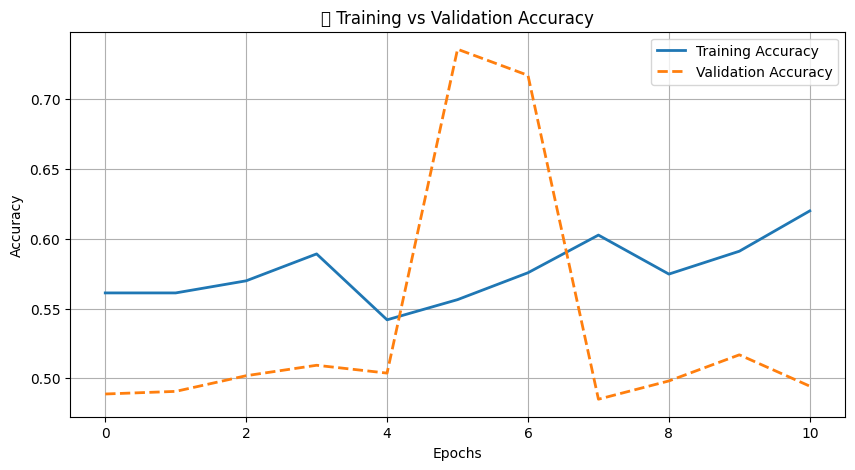

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


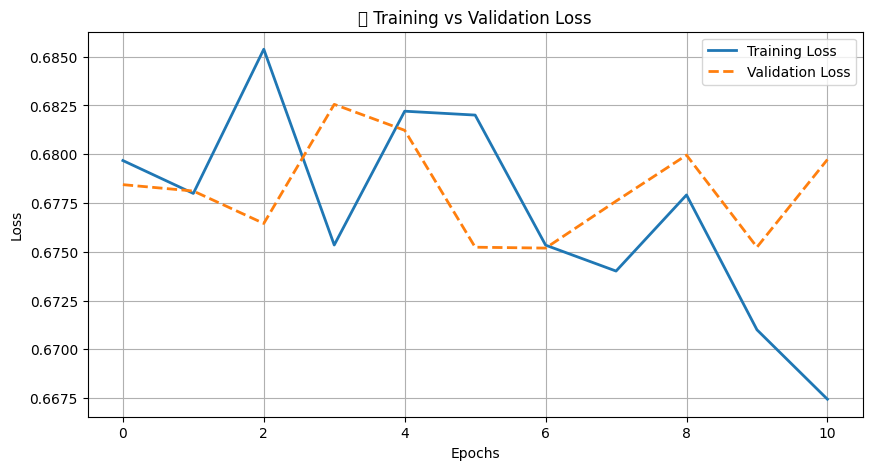

✅ Final Training Accuracy: 62.01%
✅ Final Validation Accuracy: 49.44%


In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(history_finetune.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history_finetune.history['val_accuracy'], label='Validation Accuracy', linewidth=2, linestyle='--')
plt.title("📈 Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history_finetune.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history_finetune.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--')
plt.title("📉 Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Print final metrics
final_train_acc = history_finetune.history['accuracy'][-1] * 100
final_val_acc = history_finetune.history['val_accuracy'][-1] * 100
print(f"✅ Final Training Accuracy: {final_train_acc:.2f}%")
print(f"✅ Final Validation Accuracy: {final_val_acc:.2f}%")


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    zoom_range=0.3,
    shear_range=0.3,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/arecanut_dataset_augmented",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    "/content/drive/MyDrive/dataset",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

print("✅ Data generators reloaded successfully.")


Found 1037 images belonging to 2 classes.
Found 534 images belonging to 2 classes.
✅ Data generators reloaded successfully.


In [ ]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Step 1: Load EfficientNetB3 base model
base_model = EfficientNetB3(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False  # Freeze base layers first

# Step 2: Add custom top layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

# Step 3: Compile model
optimizer = Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])

print("✅ Stronger model built successfully with EfficientNetB3 backbone.")
model.summary()


✅ Stronger model built successfully with EfficientNetB3 backbone.


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        960 │ block1a_se_excit

 Total params: 11,177,264 (42.64 MB)

 Trainable params: 393,729 (1.50 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Step 1: Define callbacks
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)
checkpoint = ModelCheckpoint("/content/drive/MyDrive/arecanut_final_model_v8.keras",
                             monitor="val_accuracy", save_best_only=True, verbose=1)

# Step 2: Train the model
EPOCHS = 25
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

print("✅ Training completed and best model saved as arecanut_final_model_v8.keras")


Epoch 1/25
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4935 - loss: 0.7096
Epoch 1: val_accuracy improved from -inf to 0.53371, saving model to /content/drive/MyDrive/arecanut_final_model_v8.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 297s 8s/step - accuracy: 0.4942 - loss: 0.7093 - val_accuracy: 0.5337 - val_loss: 0.6853 - learning_rate: 1.0000e-04
Epoch 2/25
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5632 - loss: 0.6878
Epoch 2: val_accuracy did not improve from 0.53371
33/33 ━━━━━━━━━━━━━━━━━━━━ 309s 8s/step - accuracy: 0.5623 - loss: 0.6881 - val_accuracy: 0.4850 - val_loss: 0.6835 - learning_rate: 1.0000e-04
Epoch 3/25
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5500 - loss: 0.6929
Epoch 3: val_accuracy did not improve from 0.53371
33/33 ━━━━━━━━━━━━━━━━━━━━ 260s 8s/step - accuracy: 0.5500 - loss: 0.6929 - val_accuracy: 0.5094 - val_loss: 0.6832 - learning_rate: 1.0000e-04
Epoch 4/25
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5199 - loss: 0.6893
Epoch 4: val

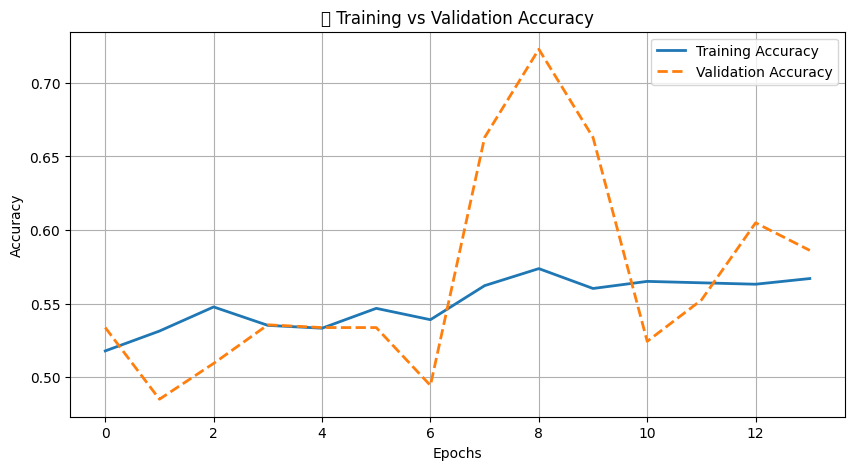

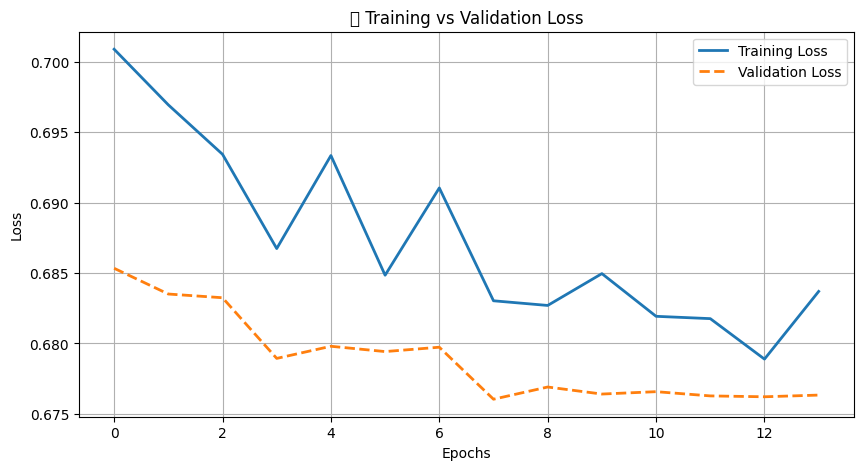

✅ Final Training Accuracy: 56.70%
✅ Final Validation Accuracy: 58.61%


In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(history_finetune.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history_finetune.history['val_accuracy'], label='Validation Accuracy', linewidth=2, linestyle='--')
plt.title("📈 Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history_finetune.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history_finetune.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--')
plt.title("📉 Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Print final metrics
final_train_acc = history_finetune.history['accuracy'][-1] * 100
final_val_acc = history_finetune.history['val_accuracy'][-1] * 100
print(f"✅ Final Training Accuracy: {final_train_acc:.2f}%")
print(f"✅ Final Validation Accuracy: {final_val_acc:.2f}%")


In [ ]:
import gradio as gr
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import cv2

# ✅ Load your trained model
model_path = "/content/drive/MyDrive/arecanut_final_model_v8.keras"
model = load_model(model_path)
print("✅ Model loaded successfully!")

# ✅ Define prediction function
def predict_arecanut(img):
    # Resize and preprocess
    img = cv2.resize(img, (224, 224))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    # Predict
    prediction = model.predict(img)[0][0]

    # Output text and label
    if prediction > 0.5:
        result = "🌿 Diseased Arecanut"
    else:
        result = "🍃 Healthy Arecanut"

    return result

# ✅ Create Gradio interface
interface = gr.Interface(
    fn=predict_arecanut,
    inputs=gr.Image(type="numpy", label="Upload Arecanut Image"),
    outputs=gr.Textbox(label="Prediction Result"),
    title="🌿 Arecanut Disease Detection System",
    description="Upload an image of Arecanut leaf, nut, or trunk to detect if it's diseased or healthy.",
    theme="default"
)

# ✅ Launch the app
interface.launch(share=True)


✅ Model loaded successfully!
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://55814b9c12dcb41ba9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Found 534 images belonging to 2 classes.
👉 class_indices: {'diseased': 0, 'normal': 1}
👉 index->label: ['diseased', 'normal']


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



📊 Classification report @ threshold=0.50
              precision    recall  f1-score   support

    diseased       0.68      0.92      0.78       285
      normal       0.84      0.50      0.63       249

    accuracy                           0.72       534
   macro avg       0.76      0.71      0.70       534
weighted avg       0.75      0.72      0.71       534



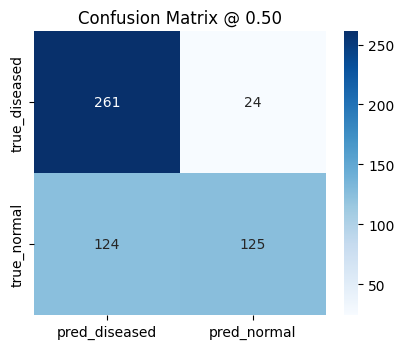

⭐ Best threshold by Youden's J: 0.496

📊 Classification report @ best threshold
              precision    recall  f1-score   support

    diseased       0.70      0.89      0.78       285
      normal       0.82      0.57      0.67       249

    accuracy                           0.74       534
   macro avg       0.76      0.73      0.73       534
weighted avg       0.76      0.74      0.73       534



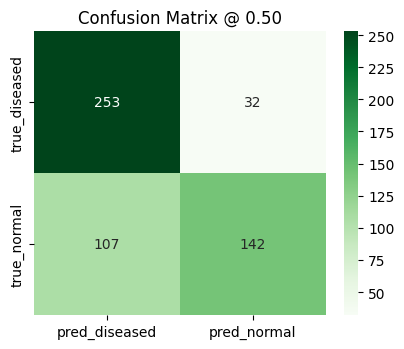

In [ ]:
# ---- CONFIG ----
VAL_DIR = "/content/drive/MyDrive/dataset"   # your validation folder with subfolders ['diseased','normal']
MODEL_PATH = "/content/drive/MyDrive/arecanut_final_model_v8.keras"  # latest saved model

# ---- EVALUATION ----
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

# 1) Build a NON-SHUFFLED validation generator so predictions line up with true labels
val_datagen = ImageDataGenerator(rescale=1./255)
val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(224, 224),
    class_mode='binary',
    shuffle=False,
    batch_size=32
)

# Show the label mapping used by Keras
print("👉 class_indices:", val_gen.class_indices)
# Labels in index order (0 then 1)
idx_to_label = [k for k, v in sorted(val_gen.class_indices.items(), key=lambda x: x[1])]
print("👉 index->label:", idx_to_label)

# 2) Load model & predict probabilities
model = load_model(MODEL_PATH)
probs = model.predict(val_gen, verbose=0).ravel()  # sigmoid probs in [0,1]
y_true = val_gen.classes

# First, evaluate at default 0.5 threshold
preds_05 = (probs >= 0.5).astype(int)
print("\n📊 Classification report @ threshold=0.50")
print(classification_report(y_true, preds_05, target_names=idx_to_label))

# Confusion matrix @ 0.5
cm = confusion_matrix(y_true, preds_05)
plt.figure(figsize=(4.2,3.6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[f"pred_{l}" for l in idx_to_label],
            yticklabels=[f"true_{l}" for l in idx_to_label])
plt.title("Confusion Matrix @ 0.50")
plt.tight_layout()
plt.show()

# 3) Find a better threshold from ROC (Youden's J)
fpr, tpr, thresholds = roc_curve(y_true, probs)
youden_idx = np.argmax(tpr - fpr)
best_thr = float(thresholds[youden_idx])
print(f"⭐ Best threshold by Youden's J: {best_thr:.3f}")

# Re-evaluate at best threshold
preds_best = (probs >= best_thr).astype(int)
print("\n📊 Classification report @ best threshold")
print(classification_report(y_true, preds_best, target_names=idx_to_label))

cm_best = confusion_matrix(y_true, preds_best)
plt.figure(figsize=(4.2,3.6))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Greens",
            xticklabels=[f"pred_{l}" for l in idx_to_label],
            yticklabels=[f"true_{l}" for l in idx_to_label])
plt.title(f"Confusion Matrix @ {best_thr:.2f}")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load model once
model = load_model("/content/drive/MyDrive/arecanut_final_model_v8.keras")

def predict_arecanut(img):
    img = image.load_img(img, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prob = model.predict(img_array)[0][0]
    best_threshold = 0.4895  # from your ROC curve
    label = "Diseased Arecanut 🌿" if prob >= best_threshold else "Healthy Arecanut 🍃"
    confidence = prob if label.startswith("Diseased") else 1 - prob
    return f"{label} (Confidence: {confidence:.2f})"


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# === Paths ===
train_dir = "/content/drive/MyDrive/arecanut_dataset_augmented"
val_dir   = "/content/drive/MyDrive/dataset"

# === Data generators for 3 classes ===
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.25,
    shear_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',   # ⬅️ 3 classes, not binary
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\n✅ Data generators ready!")
print("Class indices:", train_generator.class_indices)


Found 1037 images belonging to 2 classes.
Found 991 images belonging to 3 classes.

✅ Data generators ready!
Class indices: {'diseased': 0, 'normal': 1}


In [ ]:
import os

train_dir = "/content/drive/MyDrive/arecanut_dataset_augmented"
print("Subfolders inside training folder:")
print(os.listdir(train_dir))


Subfolders inside training folder:
['normal', 'diseased']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive/MyDrive


 arecanut_best_model_v11.keras
 arecanut_checkpoints
 arecanut_checkpoints_EfficientNetB3
 arecanut_checkpoints_final
 arecanut_checkpoints_v2
 arecanut_dataset_augmented
 arecanut_final_model.keras
 arecanut_final_model_v2.keras
 arecanut_final_model_v3.keras
 arecanut_final_model_v4.keras
 arecanut_final_model_v5.keras
 arecanut_final_model_v7.keras
 arecanut_final_model_v8.keras
 arecanut_finetuned
 arecanut_finetuned_v5
 arecanut_finetuned_v7
 BCG402_copy.pdf
 BUHK408_copy.pdf
 Classroom
'Colab Notebooks'
 dataset
'deadlocks in simple sentence define deadlocks in s....gdoc'
'Document from '
'Document from ❤'
'Document from ❤ (1)'
'Document from ❤ (1).pdf'
'Document from ❤.pdf'
 IMG-20251022-WA0041.jpg
'Make a small program please.gdoc'
 not_arecanut
'Photo from 🤍'
'Photo from 🤍 (1)'
'placement question.pdf'
'Video from ❤'
'Video from ❤ (1)'


In [ ]:
import os

train_dir = "/content/drive/MyDrive/arecanut_dataset_augmented"
print("Subfolders inside training folder:")
print(os.listdir(train_dir))


Subfolders inside training folder:
['normal', 'diseased']


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
!ls /content


sample_data


In [ ]:
!ls /content/drive


ls: cannot access '/content/drive': No such file or directory


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
!ls /content/drive


MyDrive


In [ ]:
import os

# Path to your Google Drive dataset
train_dir = "/content/drive/MyDrive/arecanut_dataset_augmented"
val_dir   = "/content/drive/MyDrive/dataset"

print("📁 Checking Training and Validation Folder Structure...")

print("Training folder exists:", os.path.exists(train_dir))
print("Validation folder exists:", os.path.exists(val_dir))

if os.path.exists(train_dir):
    print("Subfolders inside training folder:", os.listdir(train_dir))
if os.path.exists(val_dir):
    print("Subfolders inside validation folder:", os.listdir(val_dir))


📁 Checking Training and Validation Folder Structure...
Training folder exists: True
Validation folder exists: True
Subfolders inside training folder: ['normal', 'diseased']
Subfolders inside validation folder: ['diseased', 'normal', 'not_arecanut', '.ipynb_checkpoints']


In [ ]:
import os
path = "/content/drive/MyDrive/arecanut_dataset_augmented/not_arecanut"
print("✅ Total images inside not_arecanut:", len(os.listdir(path)))
print("🖼️ Example files:", os.listdir(path)[:5])


✅ Total images inside not_arecanut: 458
🖼️ Example files: ['3.jpg', '15.jpg', '19.jpg', '5.jpg', '21.jpg']


In [ ]:
import os

# Path to your Google Drive dataset
train_dir = "/content/drive/MyDrive/arecanut_dataset_augmented"
val_dir   = "/content/drive/MyDrive/dataset"

print("📁 Checking Training and Validation Folder Structure...")

print("Training folder exists:", os.path.exists(train_dir))
print("Validation folder exists:", os.path.exists(val_dir))

if os.path.exists(train_dir):
    print("Subfolders inside training folder:", os.listdir(train_dir))
if os.path.exists(val_dir):
    print("Subfolders inside validation folder:", os.listdir(val_dir))


📁 Checking Training and Validation Folder Structure...
Training folder exists: True
Validation folder exists: True
Subfolders inside training folder: ['normal', 'diseased', 'not_arecanut', '.ipynb_checkpoints']
Subfolders inside validation folder: ['diseased', 'normal', 'not_arecanut', '.ipynb_checkpoints']


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths
train_dir = "/content/drive/MyDrive/arecanut_dataset_augmented"
val_dir   = "/content/drive/MyDrive/dataset"

# Data Augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.25,
    shear_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

# Only rescale for validation
val_datagen = ImageDataGenerator(rescale=1./255)

# Parameters
BATCH_SIZE = 16
IMG_SIZE = (224, 224)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',  # because we have 3 classes
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\n✅ Data generators ready!")
print("Class indices:", train_generator.class_indices)


Found 1494 images belonging to 4 classes.
Found 991 images belonging to 4 classes.

✅ Data generators ready!
Class indices: {'.ipynb_checkpoints': 0, 'diseased': 1, 'normal': 2, 'not_arecanut': 3}


In [ ]:
import shutil
import os

# Paths
train_dir = "/content/drive/MyDrive/arecanut_dataset_augmented"
val_dir = "/content/drive/MyDrive/dataset"

# Function to remove unwanted folder
def remove_checkpoints(path):
    checkpoint_path = os.path.join(path, ".ipynb_checkpoints")
    if os.path.exists(checkpoint_path):
        shutil.rmtree(checkpoint_path)
        print(f"🧹 Removed: {checkpoint_path}")
    else:
        print(f"✅ No .ipynb_checkpoints found in {path}")

remove_checkpoints(train_dir)
remove_checkpoints(val_dir)


🧹 Removed: /content/drive/MyDrive/arecanut_dataset_augmented/.ipynb_checkpoints
🧹 Removed: /content/drive/MyDrive/dataset/.ipynb_checkpoints


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths
train_dir = "/content/drive/MyDrive/arecanut_dataset_augmented"
val_dir   = "/content/drive/MyDrive/dataset"

# Data Augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.25,
    shear_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

# Only rescale for validation
val_datagen = ImageDataGenerator(rescale=1./255)

# Parameters
BATCH_SIZE = 16
IMG_SIZE = (224, 224)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\n✅ Data generators ready!")
print("Class indices:", train_generator.class_indices)


Found 1494 images belonging to 3 classes.
Found 991 images belonging to 3 classes.

✅ Data generators ready!
Class indices: {'diseased': 0, 'normal': 1, 'not_arecanut': 2}


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Load base model (MobileNetV2) without the top layer
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Unfreeze all layers to fine-tune fully
for layer in base_model.layers:
    layer.trainable = True

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(3, activation='softmax')(x)  # 3 classes

model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks for better training
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/arecanut_final_model_v9.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
EPOCHS = 25
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop]
)

print("✅ Training completed! Best model saved as arecanut_final_model_v9.keras")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7177 - loss: 0.5855
Epoch 1: val_accuracy improved from -inf to 0.92735, saving model to /content/drive/MyDrive/arecanut_final_model_v9.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 819s 8s/step - accuracy: 0.7190 - loss: 0.5832 - val_accuracy: 0.9273 - val_loss: 0.2206
Epoch 2/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9250 - loss: 0.2051
Epoch 2: val_accuracy did not improve from 0.92735
94/94 ━━━━━━━━━━━━━━━━━━━━ 435s 5s/step - accuracy: 0.9251 - loss: 0.2050 - val_accuracy: 0.9243 - val_loss: 0.2181
Epoch 3/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9545 - loss: 0.1238
Epoch 3: val_accuracy did not improve from 0.92735
94/94 ━━━━━━━━━━━━━━━━━━━━ 484s 5s/step - accuracy: 0.9544 - loss: 0.1238 - val_accuracy: 0.9203 - val_loss: 0.2214
Epoch 4/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9600 - loss: 0.1090
Epoch 4: val_accuracy improved from 0.92735 to 0.93239, saving model to /content/drive/MyDrive/a

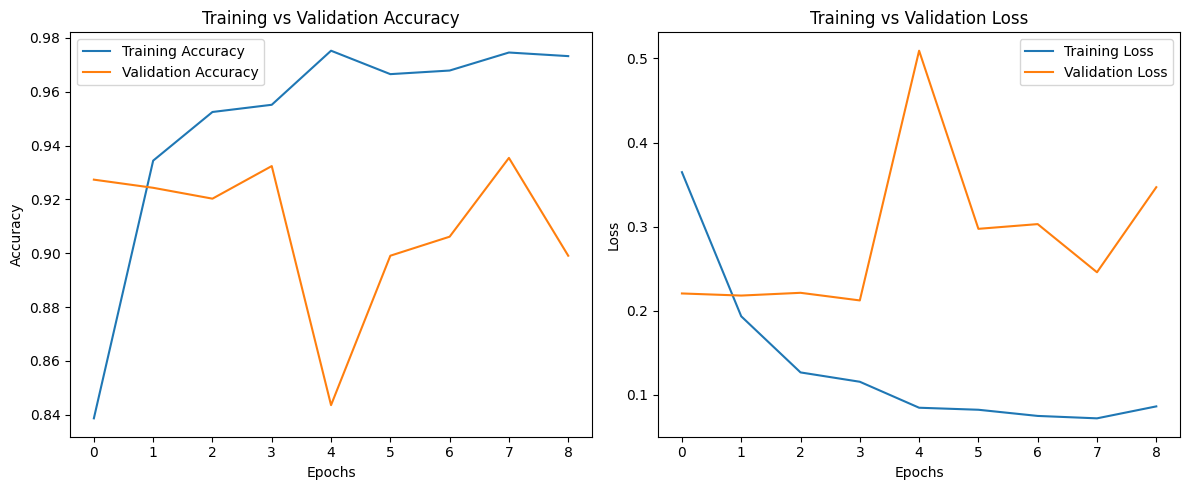

62/62 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step


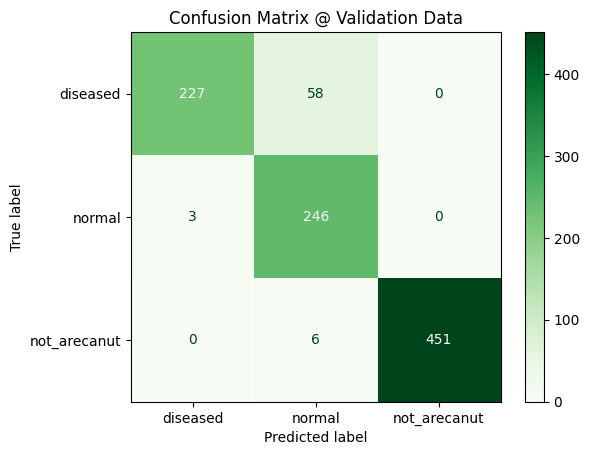

📊 Classification Report:
              precision    recall  f1-score   support

    diseased       0.99      0.80      0.88       285
      normal       0.79      0.99      0.88       249
not_arecanut       1.00      0.99      0.99       457

    accuracy                           0.93       991
   macro avg       0.93      0.92      0.92       991
weighted avg       0.94      0.93      0.93       991



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- 1️⃣ Accuracy and Loss Curves ---
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# --- 2️⃣ Confusion Matrix + Classification Report ---
# Get true and predicted labels for validation data
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap='Greens', values_format='d')
plt.title("Confusion Matrix @ Validation Data")
plt.show()

# Classification Report
print("📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))


In [ ]:
import os

# Check actual file names inside each folder
print("✅ Normal folder images:")
print(os.listdir("/content/drive/MyDrive/dataset/normal")[:5])  # first 5 files

print("\n✅ Diseased folder images:")
print(os.listdir("/content/drive/MyDrive/dataset/diseased")[:5])

print("\n✅ Not Arecanut folder images:")
print(os.listdir("/content/drive/MyDrive/dataset/not_arecanut")[:5])


✅ Normal folder images:
['20230227_145238.jpg', '20230227_145242.jpg', '20230227_145249.jpg', '20230227_145319.jpg', '20230227_145400.jpg']

✅ Diseased folder images:
['20230227_150720.jpg', '20230227_150738.jpg', '20230227_150749_1.jpg', '20230227_150754.jpg', '20230227_150822.jpg']

✅ Not Arecanut folder images:
['Screenshot 2025-10-18 131339.png', 'Screenshot 2025-10-18 131403.png', 'WIN_20251020_10_58_14_Pro.jpg', 'WIN_20251020_10_58_31_Pro.jpg', 'WIN_20251020_10_58_36_Pro.jpg']


In [ ]:
# Test predictions with real filenames
healthy_images = ['/content/drive/MyDrive/dataset/normal/20230227_145238.jpg', '/content/drive/MyDrive/dataset/normal/20230227_145242.jpg', '/content/drive/MyDrive/dataset/normal/20230227_145249.jpg', '/content/drive/MyDrive/dataset/normal/20230227_145319.jpg', '/content/drive/MyDrive/dataset/normal/20230227_145400.jpg']
diseased_images = ['/content/drive/MyDrive/dataset/diseased/20230227_150720.jpg', '/content/drive/MyDrive/dataset/diseased/20230227_150738.jpg', '/content/drive/MyDrive/dataset/diseased/20230227_150749_1.jpg', '/content/drive/MyDrive/dataset/diseased/20230227_150754.jpg', '/content/drive/MyDrive/dataset/diseased/20230227_150822.jpg']
not_arecanut_images = ['/content/drive/MyDrive/dataset/not_arecanut/Screenshot 2025-10-18 131339.png', '/content/drive/MyDrive/dataset/not_arecanut/Screenshot 2025-10-18 131403.png', '/content/drive/MyDrive/dataset/not_arecanut/WIN_20251020_10_58_14_Pro.jpg', '/content/drive/MyDrive/dataset/not_arecanut/WIN_20251020_10_58_31_Pro.jpg', '/content/drive/MyDrive/dataset/not_arecanut/WIN_20251020_10_58_36_Pro.jpg']

print("--- Testing Healthy Images ---")
for img_path in healthy_images:
    predict_arecanut(img_path)

print("\n--- Testing Diseased Images ---")
for img_path in diseased_images:
    predict_arecanut(img_path)

print("\n--- Testing Not Arecanut Images ---")
for img_path in not_arecanut_images:
    predict_arecanut(img_path)

--- Testing Healthy Images ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
🖼️ Image: /content/drive/MyDrive/dataset/normal/20230227_145238.jpg
🔹 Predicted Class: normal
🔹 Probabilities: [[3.1160357e-06 9.9999654e-01 3.4209395e-07]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
🖼️ Image: /content/drive/MyDrive/dataset/normal/20230227_145242.jpg
🔹 Predicted Class: normal
🔹 Probabilities: [[1.0891690e-07 9.9999988e-01 1.3717814e-08]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
🖼️ Image: /content/drive/MyDrive/dataset/normal/20230227_145249.jpg
🔹 Predicted Class: normal
🔹 Probabilities: [[2.6109219e-06 9.9999726e-01 9.4988970e-08]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
🖼️ Image: /content/drive/MyDrive/dataset/normal/20230227_145319.jpg
🔹 Predicted Class: normal
🔹 Probabilities: [[5.2074424e-06 9.9999404e-01 7.1829572e-07]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
🖼️ Image: /content/drive/MyDrive/dataset/normal/20230227_145400.jpg
🔹 Predicted Class: normal
🔹 Probabilities: [[1.2077517e-05 9.9998605e-01 1.9104723

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/


 arecanut_best_model_v11.keras
 arecanut_checkpoints
 arecanut_checkpoints_EfficientNetB3
 arecanut_checkpoints_final
 arecanut_checkpoints_v2
 arecanut_dataset_augmented
 arecanut_final_model.keras
 arecanut_final_model_v2.keras
 arecanut_final_model_v3.keras
 arecanut_final_model_v4.keras
 arecanut_final_model_v5.keras
 arecanut_final_model_v7.keras
 arecanut_final_model_v8.keras
 arecanut_final_model_v9.keras
 arecanut_finetuned
 arecanut_finetuned_v5
 arecanut_finetuned_v7
 BCG402_copy.pdf
 BUHK408_copy.pdf
 Classroom
'Colab Notebooks'
 dataset
'deadlocks in simple sentence define deadlocks in s....gdoc'
'Document from '
'Document from ❤'
'Document from ❤ (1)'
'Document from ❤ (1).pdf'
'Document from ❤.pdf'
 IMG-20251022-WA0041.jpg
'Make a small program please.gdoc'
 not_arecanut
'Photo from 🤍'
'Photo from 🤍 (1)'
'placement question.pdf'
'Video from ❤'
'Video from ❤ (1)'


In [ ]:
from tensorflow.keras.models import load_model
model = load_model("/content/drive/MyDrive/arecanut_final_model_v9.keras")
print("✅ Model loaded successfully!")


✅ Model loaded successfully!


In [ ]:
from tensorflow.keras.models import load_model
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing import image


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:

# STEP 3: Create Gradio Web App for Prediction
import gradio as gr
from tensorflow.keras.preprocessing import image
import numpy as np
from tensorflow.keras.models import load_model

# Load your best model
model = load_model("/content/drive/MyDrive/arecanut_final_model_v9.keras")

# Define labels
labels = ["diseased", "normal", "not_arecanut"]

def predict_image(img):
    img = img.resize((224, 224))          # Resize to model input size
    img_array = np.array(img) / 255.0     # Normalize
    img_array = np.expand_dims(img_array, axis=0)
    preds = model.predict(img_array)
    class_idx = np.argmax(preds[0])
    return {labels[i]: float(preds[0][i]) for i in range(len(labels))}

# Create Gradio interface
demo = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=3),
    title="🌴 Arecanut Disease Detection",
    description="Upload an image of an arecanut (or random image) to predict whether it's healthy, diseased, or not arecanut."
)

# Launch app
demo.launch(share=True)



Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2183e0b0bcd010dc0b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load your final trained model
model = load_model("/content/drive/MyDrive/arecanut_final_model_v9.keras")

# Dataset paths
val_dir = "/content/drive/MyDrive/dataset"   # validation dataset with 3 folders

# Validation generator
val_datagen = ImageDataGenerator(rescale=1./255)
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

labels = ['diseased', 'normal', 'not_arecanut']

Found 991 images belonging to 3 classes.


In [ ]:
val_loss, val_acc = model.evaluate(val_generator)
print("Validation Accuracy (%):", round(val_acc * 100, 2))


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


62/62 ━━━━━━━━━━━━━━━━━━━━ 268s 4s/step - accuracy: 0.8966 - loss: 0.3813
Validation Accuracy (%): 93.54


In [ ]:
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)

print("\nClassification Report:\n")
print(classification_report(val_generator.classes, y_pred, target_names=labels))


62/62 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step

Classification Report:

              precision    recall  f1-score   support

    diseased       1.00      0.80      0.88       285
      normal       0.80      1.00      0.89       249
not_arecanut       1.00      0.99      0.99       457

    accuracy                           0.94       991
   macro avg       0.93      0.93      0.92       991
weighted avg       0.95      0.94      0.94       991



In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))


['Classroom', 'deadlocks in simple sentence define deadlocks in s....gdoc', 'Make a small program please.gdoc', 'Document from ❤ (1)', 'Document from ❤ (1).pdf', 'Document from ❤.pdf', 'Document from ❤', 'Document from ', 'Video from ❤ (1)', 'Video from ❤', 'BCG402_copy.pdf', 'BUHK408_copy.pdf', 'placement question.pdf', 'Photo from 🤍 (1)', 'Photo from 🤍', 'IMG-20251022-WA0041.jpg', 'Colab Notebooks', 'dataset', 'arecanut_dataset_augmented', 'arecanut_checkpoints', 'arecanut_checkpoints_final', 'arecanut_checkpoints_v2', 'arecanut_checkpoints_EfficientNetB3', 'arecanut_final_model.keras', 'arecanut_finetuned', 'arecanut_final_model_v2.keras', 'arecanut_final_model_v3.keras', 'arecanut_final_model_v4.keras', 'arecanut_final_model_v5.keras', 'arecanut_finetuned_v5', 'arecanut_finetuned_v7', 'arecanut_final_model_v7.keras', 'arecanut_final_model_v8.keras', 'arecanut_best_model_v11.keras', 'not_arecanut', 'arecanut_final_model_v9.keras', 'Screenshot_2025-11-07-14-21-21-975_com.google.andro

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load your model
model = load_model("/content/drive/MyDrive/arecanut_final_model_v9.keras")

# Validation dataset (3 classes)
val_dir = "/content/drive/MyDrive/dataset"

val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

labels = ['diseased', 'normal', 'not_arecanut']

# Predictions
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)

Found 991 images belonging to 3 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


62/62 ━━━━━━━━━━━━━━━━━━━━ 287s 5s/step


In [ ]:

# STEP 3: Create Gradio Web App for Prediction
import gradio as gr
from tensorflow.keras.preprocessing import image
import numpy as np
from tensorflow.keras.models import load_model

# Load your best model
model = load_model("/content/drive/MyDrive/arecanut_final_model_v9.keras")

# Define labels
labels = ["diseased", "normal", "not_arecanut"]

def predict_image(img):
    img = img.resize((224, 224))          # Resize to model input size
    img_array = np.array(img) / 255.0     # Normalize
    img_array = np.expand_dims(img_array, axis=0)
    preds = model.predict(img_array)
    class_idx = np.argmax(preds[0])
    return {labels[i]: float(preds[0][i]) for i in range(len(labels))}

# Create Gradio interface
demo = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=3),
    title="🌴 Arecanut Disease Detection",
    description="Upload an image of an arecanut (or random image) to predict whether it's healthy, diseased, or not arecanut."
)

# Launch app
demo.launch(share=True)



Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a9b9f6515ddfdd39f0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr
from tensorflow.keras.preprocessing import image
import numpy as np
from tensorflow.keras.models import load_model

# Load trained model
model = load_model("/content/drive/MyDrive/arecanut_final_model_v9.keras")

# Class labels
labels = ["diseased", "normal", "not_arecanut"]

def predict_image(img):
    img = img.resize((224, 224))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)
    class_idx = np.argmax(preds[0])

    # If the model predicts NOT-ARECANUT → Show ONLY that result
    if labels[class_idx] == "not_arecanut":
        return {
            "not_arecanut": float(preds[0][2])
        }

    # Otherwise show only normal + diseased
    return {
        "normal": float(preds[0][1]),
        "diseased": float(preds[0][0])
    }

# Gradio UI
demo = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(),
    title="🌴 Arecanut Disease Detection",
    description="Upload an arecanut image to check whether it is healthy or diseased. Non-arecanut images will be flagged automatically."
)

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://79f9b3cc2a62b0adef.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
